# 2  1D Signal Visualization

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq
from scipy.signal import welch,spectrogram
from scipy.spatial.distance import cdist

# 2.1 
Utilize the ECG5000 dataset available on the Physionet Repository

(https://www.timeseriesclassification.com/description.php?Dataset=ECG5000 Date: Febru-
ary 2, 2023) for visualizing and interpreting the time-domain and frequency-
domain components of electrocardiogram signals.

In [4]:
# Load ECG5000 Dataset (Adjust the path if needed)
file_path = "../Dataset/ECG5000_TRAIN.txt"
df = pd.read_csv(file_path, delimiter=r"\s+", header=None, engine="python")


# Assign class labels (Ensure class column is correctly extracted)
file_path_ts = "../Dataset/ECG5000_TRAIN.ts"
classes = []
with open(file_path_ts, "r") as file:
    for i, line in enumerate(file):
        if i >= 9:  # Assuming first few lines are metadata
            classes.append(line.strip().split(':')[1])
df["Class"] = classes


# 2.2
Plot the ECG signal with all the heartbeats concatenated, and sub-
sets of heartbeats (clusters) – one per class, as depicted in Figure 1.

When necessary, apply centering, or amplitude/length normalization
for better visualization.

In [5]:
# Normalize each heartbeat (Min-Max Scaling)

df.iloc[:, :-1] = df.iloc[:, :-1].apply(lambda x: (x - x.mean()) / max(abs(x - x.mean())))
# Define time axis (assuming 140 time steps per signal)
time_axis = np.linspace(0, 1, 141)

# Determine the unique classes in the dataset
unique_classes = sorted(df["Class"].unique())


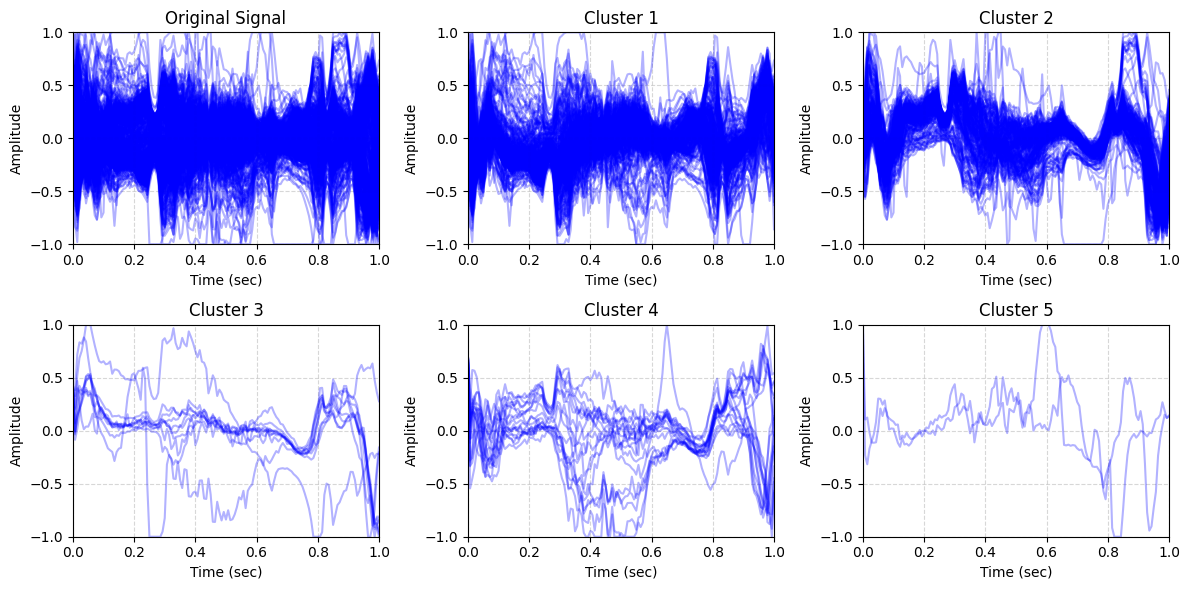

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for j in range(len(df)):
    axes[0].plot(time_axis, df.iloc[j, :-1], color='blue', alpha=0.3)
    
# Plot the hearbeats concatenated
axes[0].set_title("Original Signal")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([-1, 1])
axes[0].set_xlabel("Time (sec)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot the sub-sets of heartbeats (clusters) – one per class

for i, cls in enumerate(unique_classes):
    subset = df[df["Class"] == cls].iloc[:, :-1]
    for j in range(len(subset)):
        axes[i+1].plot(time_axis, subset.iloc[j, :], color='blue', alpha=0.3)
    axes[i+1].set_title(f'Cluster {cls}')
    axes[i+1].set_xlim([0, 1])
    axes[i+1].set_ylim([-1, 1])
    axes[i+1].set_xlabel("Time (sec)")
    axes[i+1].set_ylabel("Amplitude")
    axes[i+1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2.3
Use Fast Fourier Transform (FFT) for frequency analysis from MAT-
LAB [1] or Python [2, 3]. Plot time-domain signals, apply FFT, and

analyze both time-domain representations and frequency spectra of a

selected representative signal per heartbeat class using Python or MAT-
LAB.

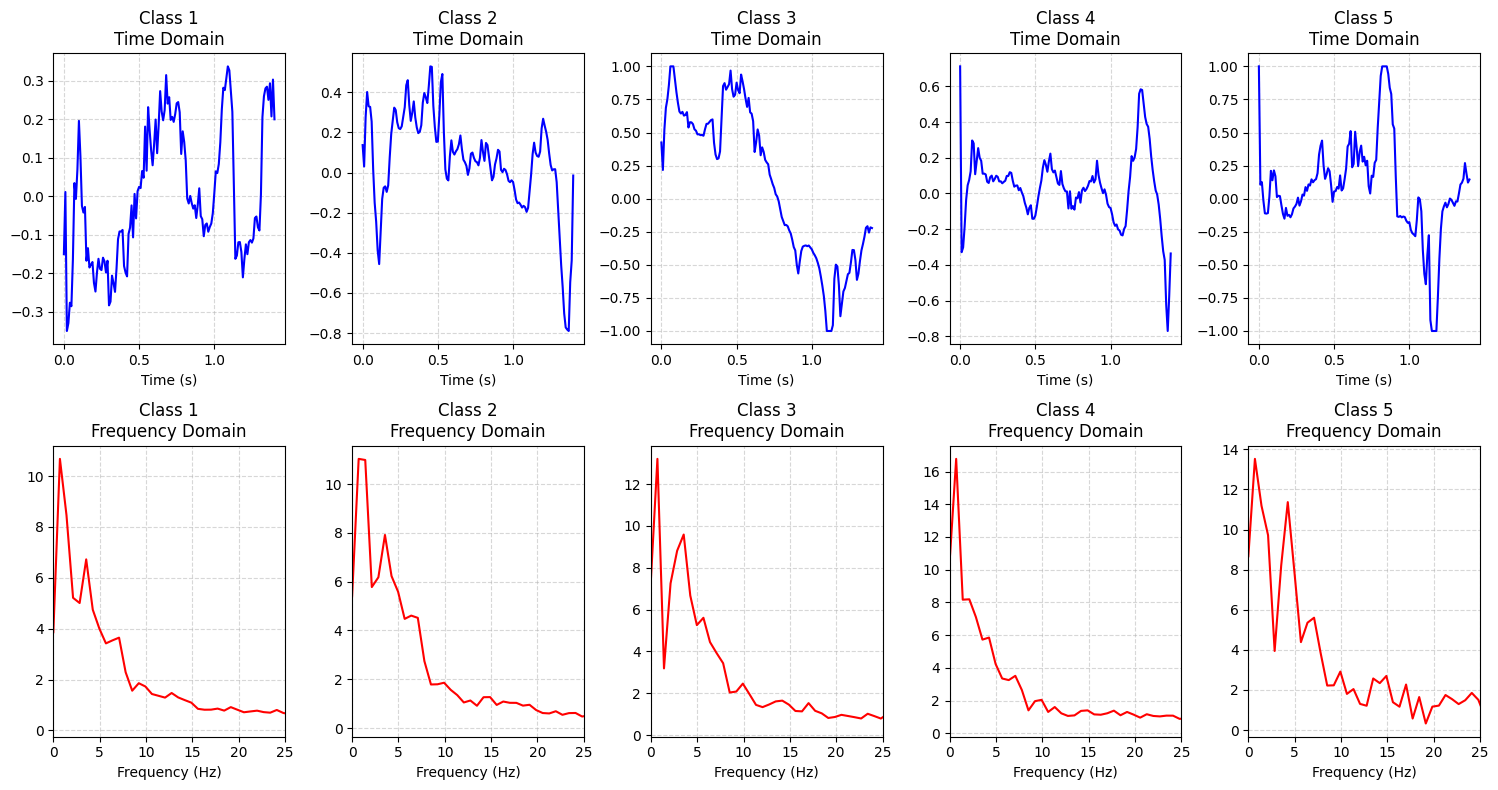

In [7]:
# Parameters
fs = 100  # Sampling frequency (Hz)
n_classes = len(df["Class"].unique())

# Initialize results
fft_results = {}
time_results = {}

# Process each class
for class_label, group in df.groupby("Class"):
    signals = group.drop("Class", axis=1).values
    
    # --- Time Domain ---
    time_results[class_label] = signals[0]  # Store first signal as representative
    
    # --- Frequency Domain ---
    n_points = signals.shape[1]
    fft_mags = np.abs(fft(signals, axis=1)[:, :n_points//2])  # Positive frequencies
    fft_results[class_label] = np.mean(fft_mags, axis=0)  # Average FFT

# Frequency axis
freq = fftfreq(n_points, d=1/fs)[:n_points//2]

# --- Plotting ---
fig, axes = plt.subplots(2, n_classes, figsize=(15, 8))  # 2 rows: Time + Freq

for i, class_label in enumerate(fft_results.keys()):
    # Time Domain Plot (Top Row)
    time = np.arange(n_points) / fs  # Convert samples to seconds
    axes[0, i].plot(time, time_results[class_label], 'b')
    axes[0, i].set_title(f'Class {class_label}\nTime Domain')
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].grid(True, ls='--', alpha=0.5)
    
    # Frequency Domain Plot (Bottom Row)
    axes[1, i].plot(freq, fft_results[class_label], 'r')
    axes[1, i].set_title(f'Class {class_label}\nFrequency Domain')
    axes[1, i].set_xlabel("Frequency (Hz)")
    axes[1, i].set_xlim(0, 25)  # Focus on ECG-relevant frequencies
    axes[1, i].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2.4
Plot and interpret PSD and spectrogram representations of a selected
representative signal per heartbeat class using Python or MATLAB.

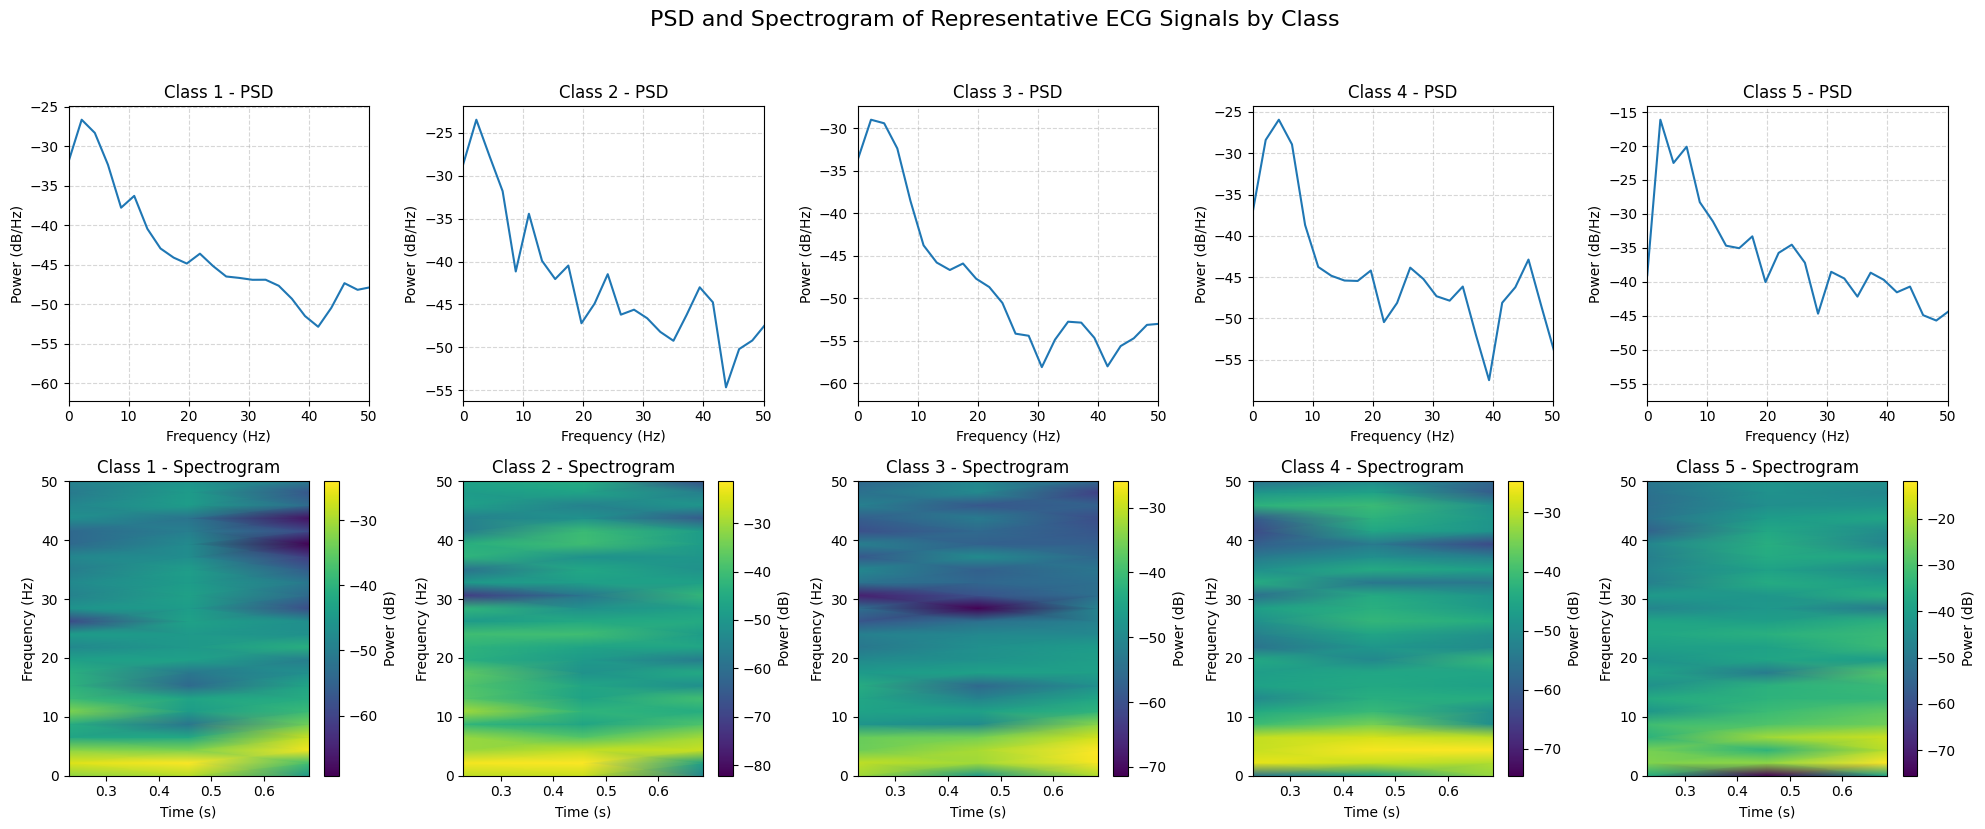

In [8]:
# Sampling frequency
fs = 140  # Assuming 1 second of data over 140 points

# Initialize results
psd_results = {}
spec_results = {}

# Unique classes
unique_classes = sorted(df["Class"].unique())

# Loop through each class
for class_label in unique_classes:
    class_signals = df[df["Class"] == class_label].iloc[:, :-1].values
    median_signal = np.median(class_signals, axis=0)
    rep_idx = np.argmin(cdist(class_signals, [median_signal]))
    rep_signal = class_signals[rep_idx]

    # --- PSD using Welch's method ---
    f_psd, Pxx = welch(rep_signal, fs=fs, window='hamming', nperseg=min(64, len(rep_signal)))
    psd_results[class_label] = (f_psd, Pxx)

    # --- Spectrogram ---
    nperseg_spec = min(64, len(rep_signal))
    noverlap_spec = nperseg_spec // 2
    f_spec, t_spec, Sxx = spectrogram(rep_signal, fs=fs, window='hamming',
                                      nperseg=nperseg_spec, noverlap=noverlap_spec)
    spec_results[class_label] = (f_spec, t_spec, Sxx)

# Plotting
n_classes = len(unique_classes)
fig, axes = plt.subplots(2, n_classes, figsize=(4 * n_classes, 8))
plt.suptitle("PSD and Spectrogram of Representative ECG Signals by Class", fontsize=16, y=1.03)

# Plot PSDs
for i, class_label in enumerate(unique_classes):
    f, Pxx = psd_results[class_label]
    axes[0, i].plot(f, 10 * np.log10(Pxx))
    axes[0, i].set_title(f"Class {class_label} - PSD")
    axes[0, i].set_xlabel("Frequency (Hz)")
    axes[0, i].set_ylabel("Power (dB/Hz)")
    axes[0, i].set_xlim([0, 50])
    axes[0, i].grid(True, linestyle='--', alpha=0.5)

# Plot Spectrograms
for i, class_label in enumerate(unique_classes):
    f_spec, t_spec, Sxx = spec_results[class_label]
    im = axes[1, i].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
    axes[1, i].set_title(f"Class {class_label} - Spectrogram")
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Frequency (Hz)")
    axes[1, i].set_ylim([0, 50])
    plt.colorbar(im, ax=axes[1, i], label="Power (dB)")

plt.tight_layout()
plt.show()